"""
Notebook 01_ingest_and_profile

Objectif :
- Charger la trace GPX de la Via Podiensis (sans altitude)
- Recalculer l'altitude via SRTM
- Reverse geocoding avec cache pour ajouter le nom des lieux
- Calculer distance, dénivelé, pente
- Préparer les sorties GeoJSON + CSV
"""


In [2]:
import gpxpy
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
import math
import os

import srtm  # pip install srtm.py

GPX_PATH = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/via-podiensis-full-route.gpx"

OUT_GEOJSON = "data_raw/route_srtm.geojson"
OUT_PROFILE = "data_raw/profile_srtm.csv"


In [3]:
with open(GPX_PATH, "r", encoding="utf-8") as f:
    gpx = gpxpy.parse(f)

points = []
for track in gpx.tracks:
    for segment in track.segments:
        for p in segment.points:
            points.append({
                "lon": p.longitude,
                "lat": p.latitude,
                "elevation_gpx": p.elevation,
                "time": p.time
            })

df = pd.DataFrame(points)
df.head()


,lon,lat,elevation_gpx,time
0,3.88478,45.04559,None,None
1,3.88396,45.04557,None,None
2,3.88319,45.04553,None,None
3,3.88284,45.04545,None,None
4,3.88250,45.04535,None,None


In [4]:
import srtm

elevation_data = srtm.get_data()

def get_srtm_elevation(lat, lon):
    elev = elevation_data.get_elevation(lat, lon)
    return float(elev) if elev is not None else None

df["elevation"] = df.apply(lambda row: get_srtm_elevation(row["lat"], row["lon"]), axis=1)

print(df[["lon", "lat", "elevation_gpx", "elevation"]].head(10))
print(df["elevation"].describe())


       lon       lat elevation_gpx  elevation
0  3.88478  45.04559          None      680.0
1  3.88396  45.04557          None      662.0
2  3.88319  45.04553          None      652.0
3  3.88284  45.04545          None      652.0
4  3.88250  45.04535          None      640.0
5  3.88264  45.04486          None      649.0
6  3.88272  45.04442          None      649.0
7  3.88281  45.04422          None      649.0
8  3.88288  45.04394          None      647.0
9  3.88277  45.04374          None      647.0
count    14765.000000
mean       418.901185
std        363.719574
min         56.000000
25%        153.000000
50%        260.000000
75%        592.000000
max       1370.000000
Name: elevation, dtype: float64


In [5]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2.0)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2.0)**2
    return 2 * R * math.asin(math.sqrt(a))

df = df.reset_index(drop=True)

# Nettoyage altitude
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")
df["elevation"] = df["elevation"].fillna(method="ffill").fillna(method="bfill")

# Distance cumulée
distances = [0.0]
cumdist = 0.0
for i in range(1, len(df)):
    d = haversine(df.loc[i-1,"lon"], df.loc[i-1,"lat"],
                  df.loc[i,"lon"], df.loc[i,"lat"])
    cumdist += d
    distances.append(cumdist)

df["distance_m"] = distances

# Profil
df["elevation_diff"] = df["elevation"].diff().fillna(0.0)
df["elevation_diff"] = df["elevation_diff"].replace([float("inf"), float("-inf")], 0.0)
df["slope"] = df["elevation_diff"] / df["distance_m"].diff().replace(0, pd.NA)

df[["distance_m", "elevation", "elevation_diff", "slope"]].head()


C:\Users\cello\AppData\Local\Temp\ipykernel_11632\3620846252.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["elevation"] = df["elevation"].fillna(method="ffill").fillna(method="bfill")


,distance_m,elevation,elevation_diff,slope
0,0.000000,680.0,0.0,NaN
1,64.460946,662.0,-18.0,-0.279239
2,125.118634,652.0,-10.0,-0.164860
3,154.019208,652.0,0.0,0.000000
4,182.953059,640.0,-12.0,-0.414739


In [6]:
import requests
import time
import json
import os
from pathlib import Path

CACHE_FILE = "data_raw/geocode_cache.json"
MIN_DIST_M = 250  # 1 appel API tous les 250 mètres maximum


def load_cache(path=CACHE_FILE):
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_cache(cache, path=CACHE_FILE):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False)


def _nominatim_call(lat, lon):
    """Appel Nominatim brut avec retry simple."""
    url = "https://nominatim.openstreetmap.org/reverse"
    params = {"lat": lat, "lon": lon, "format": "json", "zoom": 14, "addressdetails": 1}
    for attempt in range(3):
        try:
            r = requests.get(
                url, params=params,
                headers={"User-Agent": "ViaPodiensisProject"},
                timeout=10
            )
            r.raise_for_status()
            addr = r.json().get("address", {})
            return (
                addr.get("hamlet") or addr.get("village") or addr.get("town") or
                addr.get("city") or addr.get("locality") or addr.get("municipality") or
                addr.get("county") or addr.get("state") or "Lieu inconnu"
            )
        except Exception:
            time.sleep(2 ** attempt)
    return "Lieu inconnu"


def add_place_names(df, min_dist_m=MIN_DIST_M, cache_file=CACHE_FILE):
    """
    Géocode uniquement 1 point tous les `min_dist_m` mètres,
    puis propage le résultat (ffill) sur les points intermédiaires.
    Cache persisté sur disque entre les runs.
    """
    from tqdm.auto import tqdm

    cache = load_cache(cache_file)
    place_names = [None] * len(df)
    last_geocoded_dist = -min_dist_m  # forcer le 1er point

    # Identifier les points à géocoder (jalons spatiaux)
    to_geocode = []
    for i, row in df.iterrows():
        if row["distance_m"] - last_geocoded_dist >= min_dist_m:
            to_geocode.append(i)
            last_geocoded_dist = row["distance_m"]

    print(f"Points GPX total : {len(df):,}")
    print(f"Appels API prévus : {len(to_geocode):,}  (~{len(to_geocode)//60} min)")

    for i in tqdm(to_geocode, desc="Reverse geocoding"):
        lat = round(df.loc[i, "lat"], 3)   # résolution ~110 m, cache plus efficace
        lon = round(df.loc[i, "lon"], 3)
        key = f"{lat},{lon}"

        if key not in cache:
            cache[key] = _nominatim_call(lat, lon)
            time.sleep(1)          # respecter la politique Nominatim
            if len(cache) % 50 == 0:
                save_cache(cache, cache_file)   # sauvegarde intermédiaire

        place_names[df.index.get_loc(i)] = cache[key]

    save_cache(cache, cache_file)  # sauvegarde finale

    # Propager les noms vers les points intermédiaires (ffill + bfill)
    import pandas as pd
    df["place_name"] = place_names
    df["place_name"] = df["place_name"].ffill().bfill()
    return df


# --- Utilisation ---
df = add_place_names(df, min_dist_m=500)
df[["lat", "lon", "distance_m", "place_name"]].head(20)

c:\Users\cello\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Points GPX total : 14,765
Appels API prévus : 1,378  (~22 min)


Reverse geocoding: 100%|██████████| 1378/1378 [30:16<00:00,  1.32s/it]


,lat,lon,distance_m,place_name
0,45.04559,3.88478,0.000000,Le Puy-en-Velay
1,45.04557,3.88396,64.460946,Le Puy-en-Velay
2,45.04553,3.88319,125.118634,Le Puy-en-Velay
3,45.04545,3.88284,154.019208,Le Puy-en-Velay
4,45.04535,3.88250,182.953059,Le Puy-en-Velay
5,45.04486,3.88264,238.537686,Le Puy-en-Velay
6,45.04442,3.88272,287.865517,Le Puy-en-Velay
7,45.04422,3.88281,311.201550,Le Puy-en-Velay
8,45.04394,3.88288,342.818128,Le Puy-en-Velay
9,45.04374,3.88277,366.677342,Le Puy-en-Velay


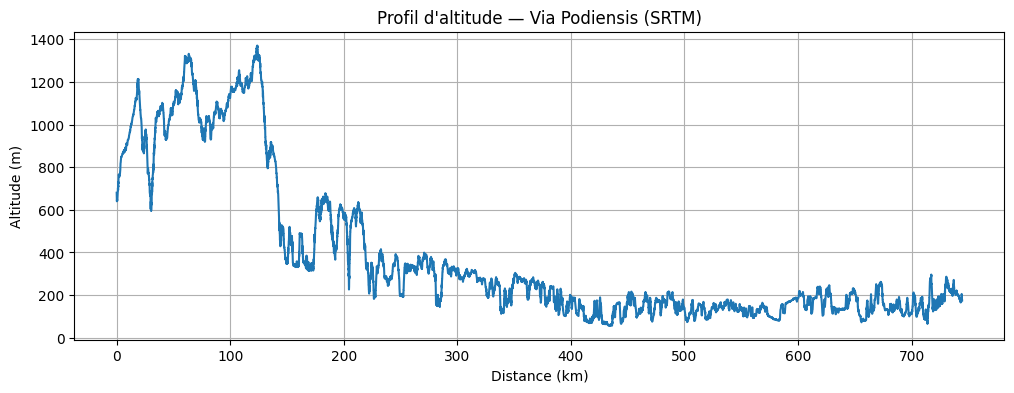

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["distance_m"] / 1000, df["elevation"])
plt.xlabel("Distance (km)")
plt.ylabel("Altitude (m)")
plt.title("Profil d'altitude — Via Podiensis (SRTM)")
plt.grid(True)
plt.show()


In [8]:
coords = list(zip(df["lon"], df["lat"]))
line = LineString(coords)
gdf_line = gpd.GeoDataFrame(
    {"name": ["via-podiensis-full-route-srtm"]},
    geometry=[line],
    crs="EPSG:4326"
)

os.makedirs(os.path.dirname(OUT_GEOJSON), exist_ok=True)
gdf_line.to_file(OUT_GEOJSON, driver="GeoJSON")

df[["distance_m","elevation","elevation_diff","slope","lon","lat","time"]].to_csv(OUT_PROFILE, index=False)

print("Exporté GeoJSON:", OUT_GEOJSON)
print("Exporté profil CSV:", OUT_PROFILE)


Exporté GeoJSON: data_raw/route_srtm.geojson
Exporté profil CSV: data_raw/profile_srtm.csv
